In [ ]:
import numpy as np
from numpy import mean
from numpy import std
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
import xgboost
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix
import pickle



In [ ]:
import io
import cv2
import os                                                                   
import glob             
#df = pd.read_excel(io.BytesIO(uploaded['Data.xlsx']))


folder_path ='/content'

# glob.glob returns all paths matching the pattern.
excel_files = list(glob.glob(os.path.join(folder_path, '*.xls*')))
mod_dates = [os.path.getmtime(f) for f in excel_files]
print(mod_dates)
# sort by mod_dates.
file_date = sorted(zip(excel_files, mod_dates),reverse=True)
print("*"*100)
print(file_date)
newest_file_path = file_date[0][0]
df = pd.read_excel(newest_file_path)

[1658565260.185181]
****************************************************************************************************
[('/content/Data.xlsx', 1658565260.185181)]


In [ ]:
# Setting input and output variables
labels = np.array(df.columns.values)
n = 0 
for col in df.columns:
    n = n+1
    print(n,' ' ,col,'\n')

y_num = int(input('\nType the corresponding number for your output variable - '))
X = df.drop([labels[y_num-1]], axis = 1)
Y = df[(labels[y_num-1])]
m = -1
o = -1

normalize_variables = np.zeros(len(labels))
normalize_variables_name = np.empty(len(labels), dtype = "<U20")

for col in X.columns:
    m = m+1
    print('Do you want to normalize',col,'?(Enter 1 for yes and 0 for no)')
    normalize_variables[m]= int(input())
    if (normalize_variables[m]!=0):
      o=o+1
      normalize_variables_name[o] = labels[m]

p = 0
object = StandardScaler()

while (normalize_variables_name[p] !=''):
  X[normalize_variables_name[p]] = object.fit_transform(df[[normalize_variables_name[p]]])
  p=p+1
  

print('\nYour input variables\n\n',X,'\n\nYour output variables\n\n',Y)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

m = -1
o = -1

normalize_variables = np.zeros(len(labels))
normalize_variables_name = np.empty(len(labels), dtype = "<U20")

1   Age 

2   Sex 

3   Headache 

4   Dementia 

5   GCS 

6   Motor weakness 

7   Midline Shift 

8   CSDH size 

9   Pre-morbid QoL 

10   Anticoagulation 

11   Acceptance Status 


Type the corresponding number for your output variable - 11
Do you want to normalize Age ?(Enter 1 for yes and 0 for no)
1
Do you want to normalize Sex ?(Enter 1 for yes and 0 for no)
0
Do you want to normalize Headache ?(Enter 1 for yes and 0 for no)
0
Do you want to normalize Dementia ?(Enter 1 for yes and 0 for no)
0
Do you want to normalize GCS ?(Enter 1 for yes and 0 for no)
0
Do you want to normalize Motor weakness ?(Enter 1 for yes and 0 for no)
0
Do you want to normalize Midline Shift ?(Enter 1 for yes and 0 for no)
0
Do you want to normalize CSDH size ?(Enter 1 for yes and 0 for no)
0
Do you want to normalize Pre-morbid QoL ?(Enter 1 for yes and 0 for no)
0
Do you want to normalize Anticoagulation ?(Enter 1 for yes and 0 for no)
0

Your input variables

            Age  Sex  Headache  Dementia

In [ ]:
# Setting which models you want to train on
model_names = ['Logistic Regression','Support Vector Machine','Decision Tree','k-Nearest Neighbour','Extreme Gradient Boosting','Random Forest']
model_chosen = np.zeros(len(model_names))
for i in range(len(model_names)):
  print('Do you want a',model_names[i],'model? (Enter 1 for yes and 0 for no)')
  model_chosen[i] = int(input())


Do you want a Logistic Regression model? (Enter 1 for yes and 0 for no)
1
Do you want a Support Vector Machine model? (Enter 1 for yes and 0 for no)
1
Do you want a Decision Tree model? (Enter 1 for yes and 0 for no)
1
Do you want a k-Nearest Neighbour model? (Enter 1 for yes and 0 for no)
1
Do you want a Extreme Gradient Boosting model? (Enter 1 for yes and 0 for no)
1
Do you want a Random Forest model? (Enter 1 for yes and 0 for no)
1


In [ ]:
# Setting what tests you want to run
test_names = ['accuracy','Sensitivity/Recall','PPV/Precision','Specificity','ROC AUC','Brier score','confusion matrix','Feature Importance Scores','Shap Feature Importance','Partial Dependence Plots']
test_chosen = np.zeros(len(test_names))
for i in range(len(test_names)):
  print('Do you want a',test_names[i],'? (Enter 1 for yes and 0 for no)')
  test_chosen[i] = int(input())

Do you want a accuracy ? (Enter 1 for yes and 0 for no)
1
Do you want a Sensitivity/Recall ? (Enter 1 for yes and 0 for no)
1
Do you want a PPV/Precision ? (Enter 1 for yes and 0 for no)
1
Do you want a Specificity ? (Enter 1 for yes and 0 for no)
1
Do you want a ROC AUC ? (Enter 1 for yes and 0 for no)
1
Do you want a Brier score ? (Enter 1 for yes and 0 for no)
1
Do you want a confusion matrix ? (Enter 1 for yes and 0 for no)
1
Do you want a Feature Importance Scores ? (Enter 1 for yes and 0 for no)
1
Do you want a Shap Feature Importance ? (Enter 1 for yes and 0 for no)
1
Do you want a Partial Dependence Plots ? (Enter 1 for yes and 0 for no)
1


In [ ]:
def test (model,name):
  Y_pred = model.predict(X_test)
  cm = confusion_matrix(Y_test,Y_pred)
  probs = model.predict_proba(X_test)[:, 1]

  if (test_chosen[0] == 1):
    print("Accuracy:",metrics.accuracy_score(Y_test, Y_pred))
  if (test_chosen[1] == 1):
    print("Recall:",metrics.recall_score(Y_test, Y_pred))
  if (test_chosen[2] == 1):
    print("Precision:",metrics.precision_score(Y_test, Y_pred))
#  if (test_chosen[3] == 1): Speficity
  if (test_chosen[4] == 1):
    print("ROC AUC:",metrics.roc_auc_score(Y_test, Y_pred))
  if (test_chosen[5] == 1):
    print("Brier score:",metrics.brier_score_loss(Y_test, probs > 0.5))
  if (test_chosen[6] == 1):  
    ax = plt.subplot()
    sns.heatmap(cm , annot = True, ax = ax);
    ax.set_xlabel('Predicted labels'); ax.set_ylabel('Actual labels');
    ax.set_title('Confusion Matrix');
    ax.xaxis.set_ticklabels(['True','False']); ax.yaxis.set_ticklabels(['True','False']);
  if (test_chosen[7] == 1):
    importance = model.coef_[0]
    for i,v in enumerate(importance):
      print('Feature: %0d, Score: %.5f' % (i,v))
    fig, ax = plt.subplots()
    plt.bar([x for x in range(len(importance))], importance)
    plt.xlabel("Predictor variables")
    plt.ylabel("Feature Importance Scores")
    plt.show()
#  if (test_chosen[8] == 1): Shap importance
#  if (test_chosen[9] == 1): Partial Dependence Plots


Accuracy: 0.9333333333333333
Recall: 0.9047619047619048
Precision: 0.8636363636363636
ROC AUC: 0.9246031746031745
Brier score: 0.06666666666666667
Feature: 0, Score: -0.53128
Feature: 1, Score: -0.05670
Feature: 2, Score: 0.94813
Feature: 3, Score: -0.87338
Feature: 4, Score: -0.01805
Feature: 5, Score: 1.23506
Feature: 6, Score: 1.00428
Feature: 7, Score: 2.62412
Feature: 8, Score: -2.55444
Feature: 9, Score: -0.28568


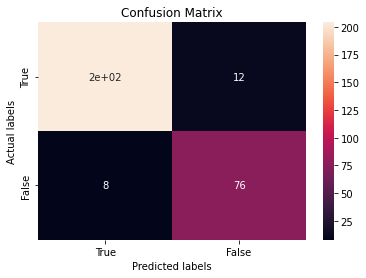

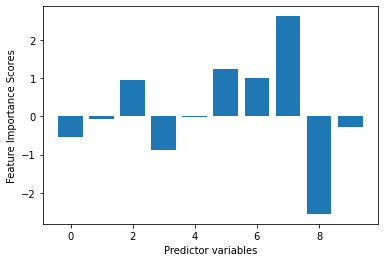

Accuracy: 0.9766666666666667
Recall: 0.9166666666666666
Precision: 1.0
ROC AUC: 0.9583333333333333
Brier score: 0.023333333333333334


AttributeError: ignored

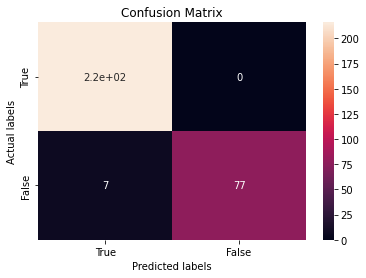

In [ ]:
if (model_chosen[0] == 1):
  Logistic_Regression_Model = LogisticRegression()
  Logistic_Regression_Model.fit(X_train,Y_train)
  pickle.dump(Logistic_Regression_Model,open('Logistic_Regression_Model.pkl', 'wb'))
  name = 'Logistic Regression'
  test (Logistic_Regression_Model,name)

if (model_chosen[1] == 1):
  Support_Vector_Machine_Model = SVC()
  Support_Vector_Machine_Model = CalibratedClassifierCV(Support_Vector_Machine_Model, method='sigmoid', cv = 4).fit(X_train, Y_train)
  pickle.dump(Support_Vector_Machine_Model,open('Support_Vector_Machine_Model.pkl', 'wb'))
  name = 'Support Vector Machine'
  test (Support_Vector_Machine_Model,name)

if (model_chosen[2] == 1):
  Decision_Tree_Model= DecisionTreeClassifier()
  Decision_Tree_Model.fit(X_train,Y_train)
  pickle.dump(Decision_Tree_Model,open('Decision_Tree_Model.pkl', 'wb'))
  name = 'Decision Tree'
  test (Decision_Tree_Model,name)

if (model_chosen[3] == 1):
  k_Nearest_Neighbour_Model= KNeighborsClassifier(n_neighbors=7)
  k_Nearest_Neighbour_Model.fit(X_train,Y_train)
  pickle.dump(k_Nearest_Neighbour_Model,open('k_Nearest_Neighbour_Model.pkl', 'wb'))
  name = 'k Nearest Neighbour'
  test (k_Nearest_Neighbour_Model,name)

if (model_chosen[4] == 1):
  Extreme_Gradient_Boosting_Model= XGBClassifier()
  Extreme_Gradient_Boosting_Model.fit(X_train,Y_train)
  pickle.dump(Extreme_Gradient_Boosting_Model,open('Extreme_Gradient_Boosting_Model.pkl', 'wb'))
  name = 'Extreme Gradient Boosting'
  test (Extreme_Gradient_Boosting_Model,name)

if (model_chosen[5] == 1):
  Random_Forest_Model = RandomForestClassifier(n_estimators = 40)
  Random_Forest_Model.fit(X_train,Y_train)
  pickle.dump(Random_Forest_Model,open('Random_Forest_Model.pkl', 'wb'))
  pickle.dump(Random_Forest_Model,open('Random_Forest_Model.pkl', 'wb'))
  name = 'Random Forest'
  test (Random_Forest_Model,name)

